# Topic Modeling: French Legislative Election Manifestos

This notebook explores topic modeling on French legislative election manifestos using different methods.

## Setup and Imports

In [1]:
import pickle
import s3fs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Gensim
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# Topic modeling
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# Visualization
import pyLDAvis
import pyLDAvis.lda_model

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


## Stopwords

In [2]:
STOPWORDS = [x.strip() for x in open('../data/stop_word_fr.txt').readlines()]
# Adding stopwords specific to the corpus
STOPWORDS += ['sciences', 'po', 'fonds', 'cevipof', 'cevipofscience']

## Loading data

The data can be loaded from either a local save if we have executed the preprocessing.ipynb or from S3. 

In [3]:
# Using local save or stocked data on S3

# Local save
# with open("../data/df_final.pkl", "rb") as f:
#     df = pickle.load(f)


# OR 

# S3 save
BUCKET = "victorgalmiche"
FILE   = "projet-nlp/df_final.pkl"

fs = s3fs.S3FileSystem(client_kwargs={'endpoint_url': 'https://minio.lab.sspcloud.fr'})
with fs.open(f"{BUCKET}/{FILE}", "rb") as f:
    df = pickle.load(f)

In [6]:
# Checking that the dataframe has been loaded successfully
print(f"\nLoaded {len(df)} documents")
print(f"Average document length: {np.mean([len(doc.split()) for doc in df.text]):.0f} words")
print(f"Min length: {min([len(doc.split()) for doc in df.text])} words")
print(f"Max length: {max([len(doc.split()) for doc in df.text])} words")


Loaded 21167 documents
Average document length: 712 words
Min length: 19 words
Max length: 4002 words


## Utils

Utility function to extract and visualize after having train a model

In [4]:
def get_topics(model, feature_names, n_top_words):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        # Get indices of top words (descending order)
        top_indices = np.argsort(-topic)[:n_top_words]
        # Map indices to words
        top_words = [feature_names[i] for i in top_indices]
        topics.append(top_words)
    return topics

def display_topics(topics):
    for i, topic in enumerate(topics):
        print(f"Topic {i}:")
        print("  " + ", ".join(topic))
        print()

## Selecting the good number of topics

We need to select a 'good' number of topics. We do this by comparing various coherence scores w/ gensim. We only use 1000 texts and use the NMF model to limit the computation time. 

In [9]:
n_features=1000
tfidf_vectorizer = TfidfVectorizer(max_features=n_features, stop_words=STOPWORDS)

sample = df.lemmatized_text[:1000]
tfidf = tfidf_vectorizer.fit_transform(sample)

analyzer = tfidf_vectorizer.build_analyzer()

tokenized_texts = [
    analyzer(doc)
    for doc in sample
]

dictionary = Dictionary(tokenized_texts)

# Optional but recommended:
dictionary.filter_extremes(no_below=5, no_above=0.95)

In [10]:
feature_names = tfidf_vectorizer.get_feature_names_out()

# for each number of topics, we will compute the 4 metrics
topic_range = [5, 10, 15, 20, 30]
coherence_metrics = ['u_mass', 'c_v', 'c_uci', 'c_npmi']
results={}
for metrics in coherence_metrics:
    results[metrics] = {}

for k in topic_range:
    # fit the model with k topics
    nmf = NMF(n_components=k, random_state=42)

    W = nmf.fit_transform(tfidf)
    topics = get_topics(nmf, feature_names, 10)
    for met in coherence_metrics:

        coherence_model = CoherenceModel(
            topics=topics,
            texts=tokenized_texts,
            dictionary=dictionary,
            coherence=met,
            processes=1
        )

        coherence_score = coherence_model.get_coherence()
        results[met][k] =  coherence_score
        print(f"NMF coherence for {k} topic and metrics {met}: {coherence_score}")

NMF coherence for 5 topic and metrics u_mass: -0.6834542001327312
NMF coherence for 5 topic and metrics c_v: 0.6089818762802841
NMF coherence for 5 topic and metrics c_uci: -1.6243310021832884
NMF coherence for 5 topic and metrics c_npmi: 0.03934379971452431
NMF coherence for 10 topic and metrics u_mass: -0.6544933568573642
NMF coherence for 10 topic and metrics c_v: 0.6147448315617355
NMF coherence for 10 topic and metrics c_uci: -0.6815735298333917
NMF coherence for 10 topic and metrics c_npmi: 0.06267136573679166
NMF coherence for 15 topic and metrics u_mass: -0.7781936984966998
NMF coherence for 15 topic and metrics c_v: 0.5818616925214687
NMF coherence for 15 topic and metrics c_uci: -0.388216335455315
NMF coherence for 15 topic and metrics c_npmi: 0.06593469913384364
NMF coherence for 20 topic and metrics u_mass: -0.8408876018135372
NMF coherence for 20 topic and metrics c_v: 0.5608817401245605
NMF coherence for 20 topic and metrics c_uci: -0.3443764237273209
NMF coherence for 20

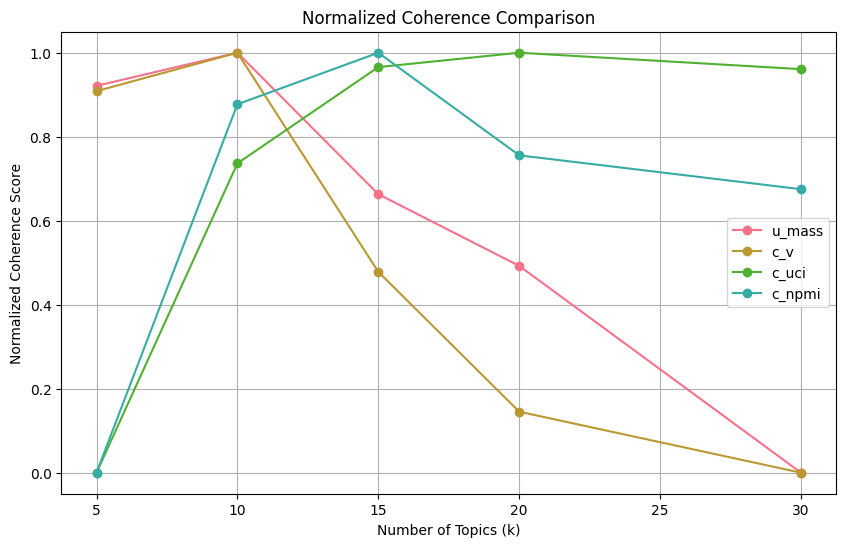

In [11]:
plt.figure(figsize=(10, 6))

for met in coherence_metrics:
    ks = sorted(results[met].keys())
    scores = np.array([results[met][k] for k in ks])

    # Min-max normalize per metric
    norm_scores = (scores - scores.min()) / (scores.max() - scores.min())

    plt.plot(ks, norm_scores, marker='o', label=met)

plt.xlabel("Number of Topics (k)")
plt.ylabel("Normalized Coherence Score")
plt.title("Normalized Coherence Comparison")
plt.legend()
plt.grid(True)
plt.show()

## Encoding w/ vectorizers

In [5]:
n_features = 1000
n_topics = 10

# Encode the texts w/ CoutnVectorizer
tf_vectorizer = CountVectorizer(max_df=0.95, min_df=5, max_features=n_features, stop_words=STOPWORDS)
doc_term_matrix = tf_vectorizer.fit_transform(df.lemmatized_text)

# OR Encode the texts w/ TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=n_features, stop_words=STOPWORDS)
tfidf = tfidf_vectorizer.fit_transform(df.lemmatized_text)

## Latent Dirichlet Allocation

In [13]:
print(f"Training LDA model with {n_topics} topics...")

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=20,
    learning_method='online',
    n_jobs=-1,
    verbose=0
)

lda_model.fit(doc_term_matrix)

Training LDA model with 10 topics...


,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",10
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'online'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",20
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [16]:
feature_names = tf_vectorizer.get_feature_names_out()
topics = get_topics(lda_model, feature_names, n_top_words=10)
display_topics(topics)

Topic 0:
  die, der, und, für, in, zu, das, den, eine, sie

Topic 1:
  vie, pouvoir, écologiste, écologie, droit, politique, travail, vouloir, femme, ps

Topic 2:
  candidat, circonscription, majorité, france, député, juin, maire, socialiste, union, conseiller

Topic 3:
  rpr, udf, français, voter, impôt, nature, aller, million, 1993, mars

Topic 4:
  travailleur, pouvoir, falloir, entreprise, devoir, payer, patron, ouvrier, emploi, lutte

Topic 5:
  circonscription, suppléant, marchais, lutte, candidat, travailleur, ouvrière, travailleuses, luire, voter

Topic 6:
  social, politique, devoir, pouvoir, france, emploi, vie, pays, national, économique

Topic 7:
  mitterrand, voter, travailleur, gauche, petit, femme, parti, pouvoir, candidat, gouvernement

Topic 8:
  national, français, front, immigration, france, immigré, vote, famille, voix, insécurité

Topic 9:
  communiste, parti, gauche, politique, pouvoir, programme, voter, commun, candidat, changement



### Interactive Visualization with pyLDAvis

In [17]:
pyLDAvis.enable_notebook()
pyLDAvis.lda_model.prepare(lda_model, doc_term_matrix, tf_vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6     -0.001942 -0.068882       1        1  31.441111
2     -0.009626 -0.036955       2        1  20.450811
9     -0.076509 -0.001549       3        1  14.386501
1     -0.049616 -0.039851       4        1   9.024558
7     -0.122633  0.168365       5        1   5.832027
4     -0.133841  0.096175       6        1   5.759888
3     -0.001880 -0.139967       7        1   4.568698
8      0.066138 -0.280032       8        1   3.740463
5     -0.104477  0.152719       9        1   2.875811
0      0.434385  0.149976      10        1   1.920131, topic_info=                Term          Freq         Total Category  logprob  loglift
589         national  34642.000000  34642.000000  Default  30.0000  30.0000
267              die  13788.000000  13788.000000  Default  29.0000  29.0000
395         français  40890.000000  40890.000000  Default  28.0000  28.0000
262              der  11858.000000  11858.000000  Default  27.0000  27.0000
915      travailleur  27604.000000  27604.000000  Default  26.0000  26.0000
..               ...           ...           ...      ...      ...      ...
482             jean    377.555940  18379.593255  Topic10  -5.4932   0.0675
323         election    230.284624  11122.256158  Topic10  -5.9876   0.0754
623            paris    180.934570   7578.370315  Topic10  -6.2287   0.2179
883        suppléant    288.824130  20933.504046  Topic10  -5.7611  -0.3305
177  circonscription    207.388496  39047.206219  Topic10  -6.0923  -1.2852

[576 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
0         1  0.130285       000
0         2  0.012517       000
0         3  0.503142       000
0         4  0.034536       000
0         5  0.009136       000
...     ...       ...       ...
995       4  0.003368  étranger
995       6  0.146373  étranger
995       7  0.000612  étranger
995       8  0.458104  étranger
995      10  0.007655  étranger

[2163 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 3, 10, 2, 8, 5, 4, 9, 6, 1])

## Non-negative matrix factorization

In [20]:
# Define the NMF model
nmf = NMF(n_topics, random_state=42)

# Train the NMF
W = nmf.fit_transform(tfidf)

# Possible to do document/topic analysis -> see the distribution of topic for a given doc
# --> Could extend it to see the distribution of topic for a given party 
# --> See the evaluation of this distribution throughout years

In [21]:
feature_names = tfidf_vectorizer.get_feature_names_out()
topics = get_topics(nmf, feature_names, n_top_words=20)
display_topics(topics)

Topic 0:
  social, politique, devoir, vie, pouvoir, emploi, développement, entreprise, france, travail, économique, liberté, droit, loi, pays, société, français, falloir, jeune, public

Topic 1:
  udf, rpr, français, immigration, rétablir, immigré, impôt, carte, sauver, front, ps, nationalité, france, supprimer, million, national, main, corruption, voter, aller

Topic 2:
  travailleur, mitterrand, gauche, lutte, petit, voter, marchais, femme, travailleuses, ouvrier, gouvernement, entendre, travailleurs, bombe, ouvrière, atomique, ouvriere, parti, commerçant, paysan

Topic 3:
  nature, animaux, rassemblement, existence, marseille, ecologiste, bulletin, nom, activité, complet, abandon, veiller, réponse, écologique, tél, mauvais, garanti, code, adresse, renouveau

Topic 4:
  die, und, der, für, zu, das, den, in, eine, sie, von, wir, ist, werden, ein, auf, sich, im, durch, mettre

Topic 5:
  juin, majorité, candidat, maire, président, france, conseiller, député, circonscription, dimanche, 

In [14]:
# We can now assign name to the different topics

topic_label = {}
topic_label[0] = 'Economie'
topic_label[1] = 'Immigration'
topic_label[2] = 'Gauche'
topic_label[3] = 'Ecologie'
topic_label[4] = 'Mots Allemands'
topic_label[5] = 'Vote'
topic_label[6] = 'Communiste'
topic_label[7] = 'Droite'
topic_label[8] = 'Ecologie'
topic_label[9] = 'Travail'

In [16]:
# Normalize the W matrix
W_normalized = W/np.sum(W, axis=1, keepdims=True)
df["dominant_topic"] = np.argmax(W_normalized, axis=1)
df["topic_score"] = np.max(W_normalized, axis=1)


Document 21115
Dominant topic: 5 - Vote (0.460)

Sciences Po / fonds CEVIPOF ELECTIONS LEGISLATIVES - 2e TOUR DU 28 MARS 1993 5e CIRCONSCRIPTION DE
SEINE SAINT-DENIS (BOBIGNY-DRANCY) Jean-Claude GAYSSOT Député Candidat Maurice NILES Maire de Drancy
Membre honoraire du Parlement Suppléant CANDIDATS DE RASSEMBLEMENT DES FEMMES ET DES HOMMES DE
PROGRES, DE TOUS LES DEMOCRATES Madame, Mademoiselle, Monsieur, N ous voulons tout d'abord remercier
toutes celles et tous ceux qui nous ont placés en tête de tous les candidats à l'issue du premier
tour de scrutin. C'est un point d'appui qui comptera. Nous voulons en même temps vous alerter :
c'est le candidat de Le Pen que nous devons affronter dimanche prochain pour le second tour. Or, le
Front national, vous le savez bien, c'est un message de haine, d'exclusion, d'intolérance ; c'est
une volonté d'opposer entre eux les plus démunis pour mieux les soumettre aux plus puissants; c'est
une mise en cause brutale du S.M.I.C., de la Sécurité Sociale,

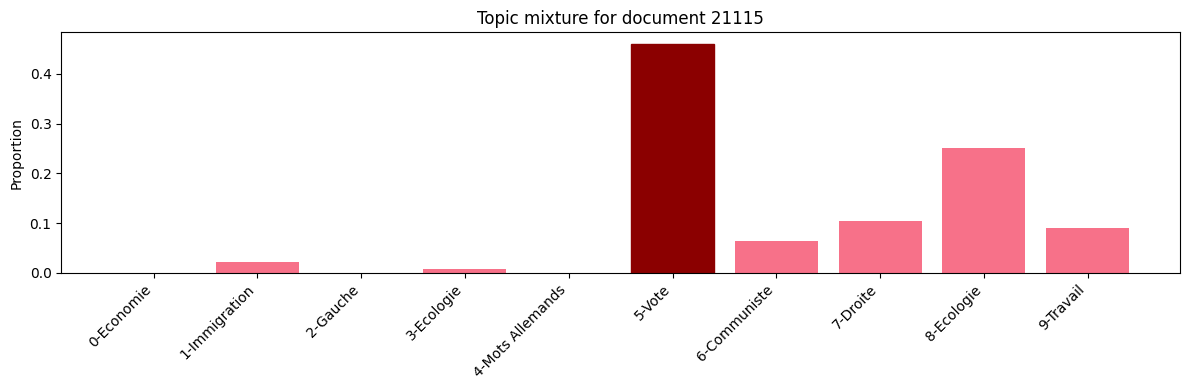


Document 15973
Dominant topic: 0 - Economie (0.658)

CONVAINCRE ENSEMBLE ! Madame, Mademoiselle, Monsieur, Chers amis, Nous avons visité les 47 communes
de la circonscription. J'ai pris la mesure de la situation. Nous sommes à un tournant de l'histoire.
La France n'a jamais été aussi riche et pourtant il n'y a jamais eu tant de gens en difficulté et en
chômage, ce qui est inadmissible ! ET NOUS? ICI, DANS LE CHER! Nous, les milliers de jeunes et moins
jeunes sans emploi, Nous qui travaillons mais dont un enfant, un parent, un ami est sans emploi,
Nous les retraités, Nous les personnes agées, Nous les agriculteurs, les artisans, les commerçants,
les prestataires de service, les petites entreprises, que les charges et les prix condamnent, Nous
de l'enseignement, de la police et de la justice, Nous de la ville et Nous de la campagne, Nous
tous, Nous souhaitons que les choses changent profondément car nous devons faire face à la crise
d'une société qui a perdu ses points de repère et ses 

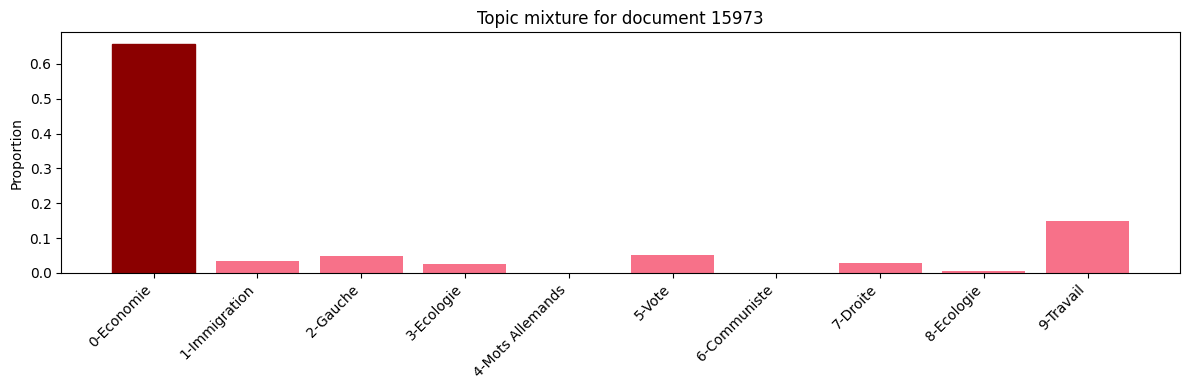


Document 2127
Dominant topic: 6 - Communiste (0.504)

ELECTIONS LEGISLATIVES DU 4 MARS 1973 23ª circonscription de Paris - 17e arrondissement (Plaine
Monceau-Batignolles) CENTRE ET RÉFORMATEURS · CENTRE DÉMOCRATE (Jean LECANUET) · MOUVEMENT
RÉFORMATEUR · CENTRE NATIONAL DES INDÉPENDANTS (Président d'honneur Antoine PINAY) Soutien
PRESENTENT : PAUL GARSON Avocat à la Cour Vice-Président du Conseil Municipal de Paris (1961-1962)
Président de la Commission des Anciens Combattants du Conseil Général (1959-1965) Croix de Guerre
(1939-1945) Campagnes d'Afrique, de France et d'Allemagne Ancien de la 1re Armée Française (Rhin et
Danube) SUPPLEANT : Yves de DARUVAR Cadre Administratif Grand Officier de la Légion d'honneur
Compagnon de la Libération Ancien de la Division Leclerc LE CHANGEMENT DANS LE CALME Les Français
aspirent au changement, mais ils veulent, dans leur grande majorité, ainsi que l'a déclaré Jean
LECANUET, qu'il s'opère dans le calme, sans bouleversement, sans crise politique, 

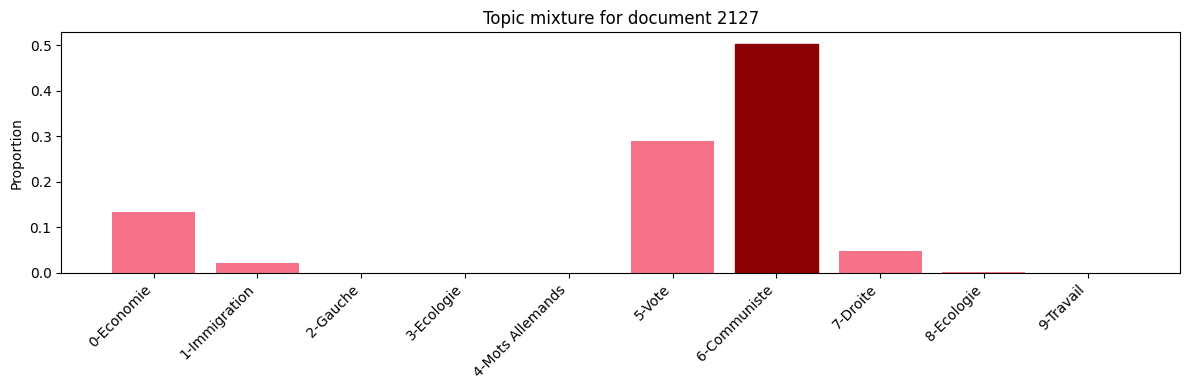


Document 17744
Dominant topic: 0 - Economie (0.485)

ELECTIONS LEGISLATIVES - MARS 1993 XIVº CIRCONSCRIPTION Gérard LAHAEYE 42 ANS DIRECTEUR DE SOCIETE
CANDIDAT INDEPENDANT Vrais Amis de Flandre, Sans parti, sans parrain, je me présente à votre choix
en Homme libre et responsable. Depuis trop longtemps, la Flandre souffre de la tempête, de ceux qui
en profitent et la négligent. Aujourd'hui, le déluge arrive avec d'autres qui voudraient dans le
mépris nous la voler, la vider. Mon instinct à protéger la valeur de ce qui peut rapporter à tous
m'oblige maintenant à barrer la route à ceux qui avouent déjà dans l'ombre ne plus avoir de
solution. Ma bataille quotidienne pour le TRAVAIL compte et comptera comme ma seule ambition au
service des uns et des autres. La VERITE de la JEUNESSE et la liberté de l'indépendance vaincront
contre la main mise sévère de quelques uns. Ensemble, tous ensemble, le 21 mars nous allons gagner
vrai, en toute liberté, pour que demain, sans promesse mais avec des

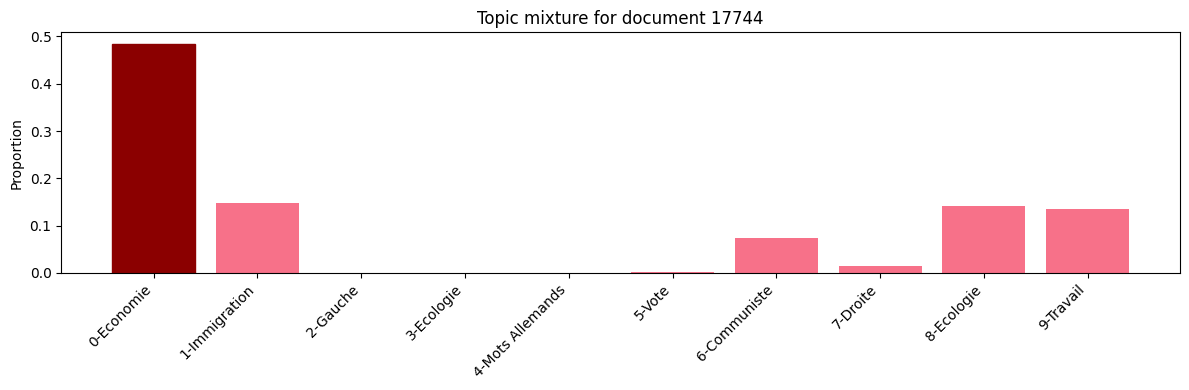


Document 17776
Dominant topic: 6 - Communiste (0.508)

Elections Législatives 21 MARS 93 18ème Circonscription POUR L'EMPLOI ET LA JUSTICE SOCIALE POUR
FAIRE DU NEUF ! avec les candidats de Rassemblement présentés par le PARTI COMMUNISTE FRANÇAIS
Edouard et TRICQUET Gérard BEZIN Madame, Mademoiselle, Monsieur, La situation ne peut plus durer
comme ça ! Le chômage, les injustices, l'incertitude du lendemain, le sentiment d'insécurité, la
drogue qui étend ses méfaits, la jeunesse sacrifiée, sont insupportables. Nous ne l'acceptons pas et
nous vous proposons de la refuser tous ensemble car il est possible de faire autrement. Jamais il
n'y a eu autant de richesses produites dans notre pays ! Les immenses progrès technologiques de ces
dernières années doivent servir à alléger la peine des hommes et non pas enrichir encore plus ceux
qui possèdent des fortunes considérables. Le chômage n'est pas une fatalité ! Pour le combattre,
nous avons soumis à votre réflexion des propositions pour la Fr

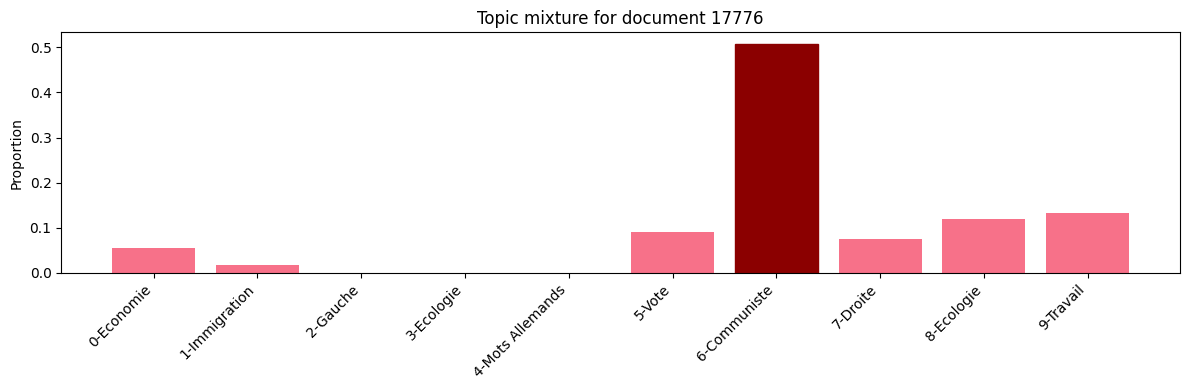

In [22]:
import textwrap

topic_names = [f"{k}-{topic_label[k]}" for k in topic_label.keys()]
    
for row in df.sample(n=5, random_state=42).itertuples():
    
    doc_id = row.Index
    topic_distribution = W_normalized[doc_id]
    dominant_topic = row.dominant_topic
    dominant_score = row.topic_score
    dominant_label = topic_label[dominant_topic]
    
    print(f"\nDocument {doc_id}")
    print(f"Dominant topic: {dominant_topic} - {dominant_label} ({dominant_score:.3f})\n")
    text = textwrap.fill(row.text, width=100)
    print(text[:1200])
    print("\n\n")
    
    # Topic distribution
    plt.figure(figsize=(12,4))
    bars = plt.bar(topic_names, topic_distribution)
    bars[dominant_topic].set_color("darkred")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Proportion")
    plt.title(f"Topic mixture for document {doc_id}")
    plt.tight_layout()
    plt.show()

## Bertopic

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

docs = df["text"].tolist()

# Encode the documents with SentenceTransformer
sentence_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = sentence_model.encode(docs, show_progress_bar=True)

# Create a CountVectorizer with French stop words
vectorizer = CountVectorizer(stop_words=STOPWORDS, ngram_range=(1, 2))

# Create the BERTopic model using the vectorizer and fit it
topic_model = BERTopic(embedding_model=sentence_model, vectorizer_model=vectorizer, nr_topics=n_topics)
topics, probs = topic_model.fit_transform(df["text"], embeddings)

In [ ]:
topic_model.get_topic_info()

In [ ]:
topic_model.visualize_documents(
    docs=docs,
    embeddings=embeddings,
    hide_annotations=True,
    topics=[0, 1, 2, 3, 4, 5,6, 7, 8, 9],
    height=600,
    width=1000
)